In [35]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from tqdm import tqdm
import seaborn
from functools import reduce
from operator import getitem
from utils.color_palettes import make_alternate_versions as make_color_palettes
seaborn.set_style('whitegrid')

# Always run from repo root regardless of notebook location
_REPO_ROOT = os.path.abspath(os.path.join(os.path.dirname(os.path.abspath("__file__")), ".."))
if os.path.basename(os.getcwd()) == "analysis":
    os.chdir("..")
sys.path.insert(0, os.getcwd())

from utils.checkpoint_info import get_token_count


In [45]:
RANKME_FINEWEB_PADDED = "rankme_fineweb_padded"
RANKME_FINEWEB_PADDED1 = "rankme_fineweb_padded_k-n"
RANKME_FINEWEB_PADDED2 = "rankme_fineweb_padded_n-k"
RANKME_FINEWEB_PADDED3 = "rankme_fineweb_padded_"
RANKME_FINEWEB_PADDED4 = "rankme_fineweb_padded__"
RANKME_FINEWEB_PADDED5 = "rankme_fineweb_padded___"
RANKME_TRAINSET_PACKED_ = "rankme_trainset_packed_"
RANKME_TRAINSET_PACKED = "rankme_trainset_packed"
RANKME_TRAINSET_PACKED_40M = "rankme_trainset_packed_40M"
FINEWEB = "fineweb"

In [ ]:
def load_results(model_name: str, dataset_name: str = 'fineweb'):
    new_path = os.path.join('results', dataset_name, f'results_{model_name}.npy')
    old_path = os.path.join('results', f'results_{model_name}.npy')
    path = new_path if os.path.exists(new_path) else old_path
    try:
        res = np.load(path, allow_pickle=True).item()
    except FileNotFoundError as e:
        if '_' not in model_name:   # alternate result versions can be missed
            print(new_path)
            raise e
        return None, None
    step_nums = sorted(res.keys())
    # print(res)
    return res, step_nums

HOOK_DEFAULTS = {
    RANKME_TRAINSET_PACKED_: ('after_final_norm', 'A'),
    # 'rankme_fineweb_padded': ('after_final_norm', 'A'),
    # 'rankme_fineweb_padded': ('after_final_norm', 'A_centered'),
    'fineweb': (),
}

def _get_ys(res, step_nums, hook):
    return [reduce(getitem, hook, res[s]) for s in step_nums]

def get_ys(dataset_name, res, step_nums, yvar, hook=None):
    if hook is None:
        hook = HOOK_DEFAULTS.get(dataset_name, ('after_final_norm', 'A'))
    return _get_ys(res, step_nums, (*hook, yvar))

def get_xs_steps(model_name, step_nums):
    return step_nums

def get_xs_tokens(model_name, step_nums):
    return [get_token_count(model_name.split('_')[0], s) for s in step_nums]


def _parse_param_count(model_name):
    """Extract parameter count from model name (e.g. 'pythia-70m' -> 70e6, 'OLMo-2-0425-1B' -> 1e9)."""
    name = model_name.lower()
    if 'pythia' in name:
        size_str = model_name.split('pythia-')[-1].split('-deduped')[0]
    elif 'olmo' in name:
        size_str = model_name.split('-')[-1]
    else:
        raise ValueError(f"Cannot extract param count from {model_name}")
    multiplier = 1e6 if size_str[-1].lower() == 'm' else 1e9
    return float(size_str[:-1]) * multiplier


def get_xs_flops(model_name, step_nums):
    num_params = _parse_param_count(model_name)
    return [num_params * s for s in step_nums]


XVAR_FNS = {
    'steps': get_xs_steps,
    'tokens': get_xs_tokens,
    'flops': get_xs_flops,
}

XVAR_LABELS = {
    'steps': 'Steps',
    'tokens': 'Pretraining tokens',
    'flops': 'Flops',
    'isoflops': 'Parameters',
}

YVAR_LABELS = {
    'alpha': r'$\alpha$',
    'rankme': 'RankMe',
}

base_colors = [
    'turquoise', 'turquoise',
    'cornflowerblue', 'cornflowerblue',
    'dodgerblue', 'dodgerblue',
    'gold', 'gold',
    'lime', 'lime',
    'darkgreen', 'darkgreen',
    'magenta', 'magenta',
    'deeppink', 'deeppink',
    'purple', 'purple',
    'brown', 'brown',
    'blue',
    'red',
]

model_name_options = [
    'pythia-14m', 'pythia-14m-deduped',
    'pythia-31m', 'pythia-31m-deduped',
    'pythia-70m', 'pythia-70m-deduped',
    'pythia-160m', 'pythia-160m-deduped',
    'pythia-410m', 'pythia-410m-deduped',
    'pythia-1b', 'pythia-1b-deduped',
    'pythia-1.4b', 'pythia-1.4b-deduped',
    'pythia-2.8b', 'pythia-2.8b-deduped',
    'pythia-6.9b', 'pythia-6.9b-deduped',
    'pythia-12b', 'pythia-12b-deduped',
    'OLMo-2-0425-1B',
    'OLMo-2-1124-7B',
]

def get_ls(model_name: str, xvar=None):
    if xvar == 'isoflops':
        return '*' if 'deduped' in model_name else 's'

    ls_exceptions = {'_': '-.', 'deduped': '--'}
    for substring, ls in ls_exceptions.items():
        if substring in model_name:
            return ls
    return '-'

def get_model_label(model_name: str):
    parts = model_name.replace('_','-').split('-')

    if parts[0] == 'pythia':
        parts = [parts[0].capitalize(), parts[1].upper(), *parts[2:]]

    if parts[0] == 'OLMo' and parts[1] == '2':
        parts = ['OLMo-2', parts[3], *parts[4:]]

    return ' '.join(parts)

SOURCE_LABELS = {
    (RANKME_TRAINSET_PACKED, None): '80M Training unc',
    (RANKME_TRAINSET_PACKED_, None): '80M Training unc... unc?',
    (RANKME_FINEWEB_PADDED, ('after_final_norm', 'A_centered')): 'new new FineWeb cent n-k',
    # (RANKME_FINEWEB_PADDED1, ('after_final_norm', 'A_centered')): 'new FineWeb cent k-n',
    # (RANKME_FINEWEB_PADDED1, ('after_final_norm', 'A')): 'new FineWeb unc k-n',
    # (RANKME_FINEWEB_PADDED2, ('after_final_norm', 'A_centered')): 'new FineWeb cent n-k',
    (RANKME_TRAINSET_PACKED_40M, ('after_final_norm', 'A_centered')): '40M Training cent',
    (RANKME_TRAINSET_PACKED_40M, ('after_final_norm', 'A')): '40M Training unc',
    # (FINEWEB, None): 'old FineWeb',
}

def get_source_label(item):
    return SOURCE_LABELS.get(item, item)


def plot_model_training(model_name: str, xvar: str = 'steps', yvar: str = 'alpha',
                        source: str = ('fineweb', None), color: str = 'k', marker: str = 'o',
                        label_source: bool = False, alternates: list[str] = []):
    source_file, hook = source
    # if source_file is in [RANKME_TRAINSET_PACKED_SQ]:
    #     yvar="sq_rankme"
    for model_name in [model_name, *(model_name+f'_{alt}' for alt in alternates)]:

        res, step_nums = load_results(model_name, dataset_name=source_file)
        if res is None:
            continue

        xs = XVAR_FNS[xvar](model_name, step_nums)
        ys = get_ys(source_file, res, step_nums, yvar, hook=hook)
        ls = get_ls(model_name)
        label = f'{get_model_label(model_name)}' + f' - {get_source_label(source)}' * label_source

        plt.plot(xs, ys, marker=marker, color=color, ls=ls, lw=3, label=label)


def plot_model_training_isoflops(model_name: str, yvar: str = 'alpha',
                                 source: str = ('fineweb',None), max_flops: int = 2e15,
                                 alternates: list[str] = []):
    source_file, hook = source

    for model_name in [model_name, *(model_name+f'_{alt}' for alt in alternates)]:

        res, step_nums = load_results(model_name, dataset_name=source_file)
        if res is None:
            continue

        flops_per_step = _parse_param_count(model_name)
        isoflops = np.array([1e13, 5e13, 1e14])
        isoflops_steps = (isoflops / flops_per_step // 1000 * 1000).astype(int)
        plot_steps = [s for s in isoflops_steps if s < max(step_nums) and s > min(step_nums)]

        ys = get_ys(source_file, res, step_nums, yvar, hook=hook)
        xs = [flops_per_step] * len(ys)
        marker = get_ls(model_name, xvar="isoflops")
        plot_colors = base_colors[:len(plot_steps)]

        plt.scatter(xs, ys, marker=marker, color=plot_colors)


In [47]:
def plot_group(
    xvar: str,
    yvar: str,
    data_sources: list[str],
    model_names: list[str],
    **kwargs
):
    palettes = make_color_palettes(base_colors, len(data_sources), method="lightness")

    for didx, data_source in enumerate(data_sources):
        for midx, model_name in enumerate(tqdm(model_names)):
            color = palettes[didx][model_name_options.index(model_name)]
            if xvar == 'isoflops':
                plot_model_training_isoflops(model_name, yvar=yvar,
                                            source=data_source,
                                            label_source=len(data_sources)>1,
                                            **kwargs)
            else:
                plot_model_training(model_name, xvar=xvar, yvar=yvar,
                                    source=data_source,
                                    color=color,
                                    label_source=len(data_sources)>1,
                                    **kwargs)

    plt.xscale('log')
    plt.xlabel(XVAR_LABELS[xvar], fontsize=14)
    plt.ylabel(YVAR_LABELS.get(yvar, yvar), fontsize=14)
    plt.legend()
    plt.show()

100%|██████████| 1/1 [00:00<00:00, 139.97it/s]


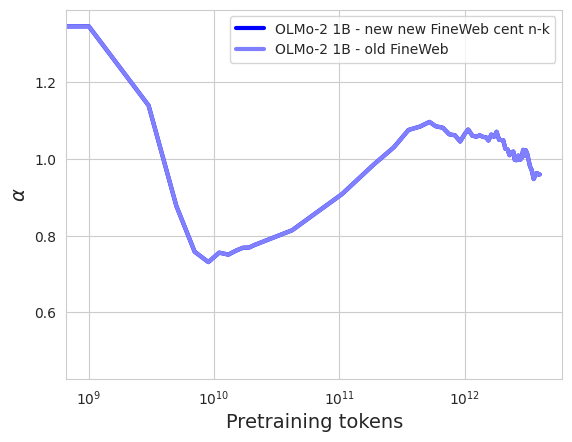

100%|██████████| 1/1 [00:00<00:00, 144.22it/s]


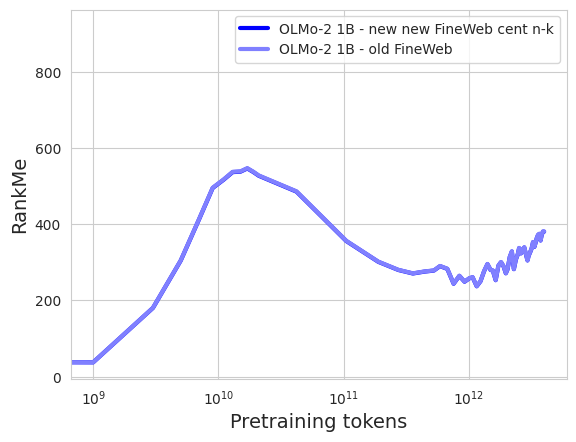

100%|██████████| 1/1 [00:00<00:00, 89.39it/s]


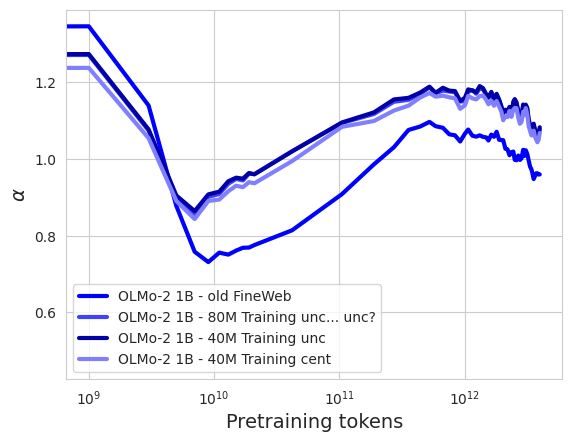

100%|██████████| 1/1 [00:00<00:00, 76.33it/s]


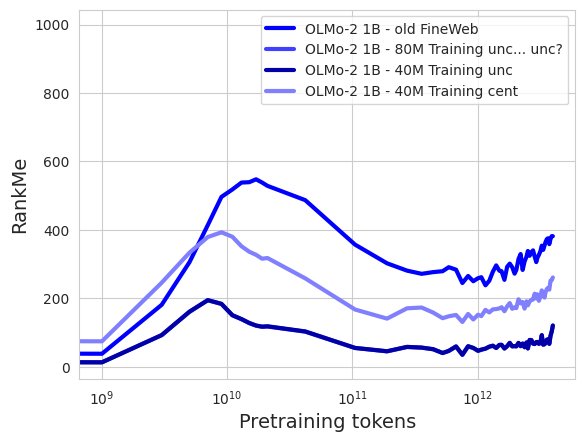

100%|██████████| 1/1 [00:00<00:00, 72.05it/s]


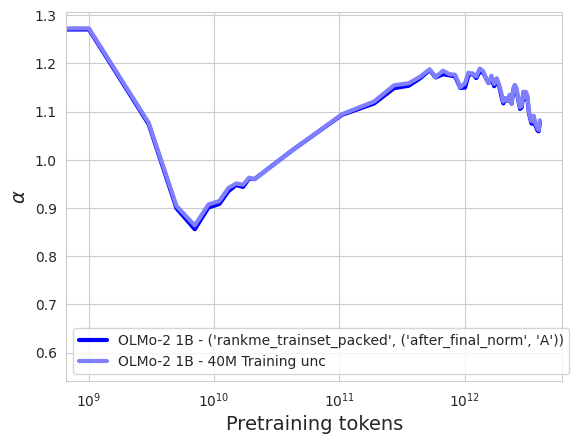

100%|██████████| 1/1 [00:00<00:00, 78.55it/s]


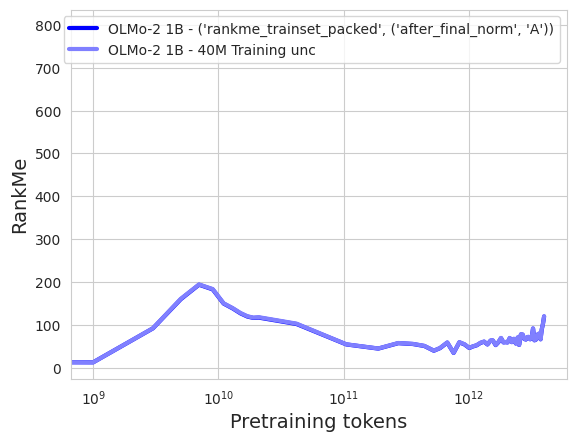

In [ ]:
filter_model_names = [
    # 'pythia-14m-deduped',
    # 'pythia-31m-deduped',
    # 'pythia-70m-deduped',
    # 'pythia-160m-deduped',
    # 'pythia-410m-deduped',
    # 'pythia-1b-deduped',
    # 'pythia-1.4b-deduped',
    # 'pythia-2.8b-deduped',
    # 'pythia-6.9b-deduped',
    # 'pythia-12b-deduped',
    # 'pythia-14m',
    # 'pythia-31m',
    # 'pythia-70m',
    # 'pythia-160m',
    # 'pythia-410m',
    # 'pythia-1b',
    # 'pythia-1.4b',
    # 'pythia-2.8b',
    # 'pythia-6.9b',
    # 'pythia-12b',
    'OLMo-2-0425-1B',
    # 'OLMo-2-1124-7B',
]

alternates = [
    # '5k'
]

# data_source = None
# dataset_name = 'fineweb'
# dataset_name = 'rankme_alpha_packed'
# if data_source is not None:
#     data_sources = [data_source]
# data_sources = [RANKME_FINEWEB_PADDED, RANKME_FINEWEB_PADDED1, RANKME_FINEWEB_PADDED1, RANKME_FINEWEB_PADDED2, RANKME_TRAINSET_PACKED, RANKME_TRAINSET_PACKED_40M]
# hookpaths = [('after_final_norm', 'A_centered'), ('after_final_norm', 'A_centered'), ('after_final_norm', 'A'), ('after_final_norm', 'A_centered'), None]
# data_sources = [*zip(data_sources, hookpaths)]

# plot_group('tokens', 'rankme', data_sources, filter_model_names, alternates=alternates, marker='')

data_sources = [FINEWEB, RANKME_TRAINSET_PACKED_, RANKME_TRAINSET_PACKED_40M, RANKME_TRAINSET_PACKED_40M]
hookpaths = [None, None, ('after_final_norm', 'A'), ('after_final_norm', 'A_centered'), ]
data_sources = [*zip(data_sources, hookpaths)]
plot_group('tokens', 'alpha', data_sources, filter_model_names, alternates=alternates, marker='')
plot_group('tokens', 'rankme', data_sources, filter_model_names, alternates=alternates, marker='')


data_sources = [RANKME_TRAINSET_PACKED, RANKME_TRAINSET_PACKED_40M]
hookpaths = [('after_final_norm', 'A'),('after_final_norm', 'A'),]
data_sources = [*zip(data_sources, hookpaths)]
plot_group('tokens', 'alpha', data_sources, filter_model_names, alternates=alternates, marker='')
plot_group('tokens', 'rankme', data_sources, filter_model_names, alternates=alternates, marker='')
